In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [68]:
df = pd.read_csv("../data/processed/customerIQ_customer_churn_features.csv")

print("Data loaded successfully.")
print(df.shape)

Data loaded successfully.
(10000, 20)


In [69]:
print(df.head())
print(df.dtypes)

  customer_id   age  gender location  tenure_months  monthly_spend  \
0     C100000  56.0  Female   Mumbai             40        1008.23   
1     C100001  69.0    Male    Delhi             31        1716.53   
2     C100002  46.0  Female   Mumbai             65        1035.82   
3     C100003  32.0    Male    Other             39        2622.21   
4     C100004  60.0    Male     Pune             24        2117.73   

   total_spend  login_frequency  support_tickets  product_usage  \
0     43296.89             20.0                1           68.0   
1     52968.01             20.0                3           87.0   
2     72203.52             23.0                7           88.0   
3    107971.82             13.0                1           68.0   
4     49767.32              4.0                2           80.0   

  subscription_type payment_method  discount_used  churn  \
0           Monthly     Debit Card              1      0   
1           Monthly            UPI              0      0

In [70]:
categorical_features = [
    "gender",
    "location",
    "subscription_type",
    "payment_method",
    "age_group",
    "tenure_group"
]

print(categorical_features)

['gender', 'location', 'subscription_type', 'payment_method', 'age_group', 'tenure_group']


In [71]:
numerical_features = [
    "age",
    "tenure_months",
    "monthly_spend",
    "total_spend",
    "login_frequency",
    "support_tickets",
    "product_usage",
    "discount_used",
    "average_monthly_spend",
    "usage_per_month",
    "support_ticket_rate"
]

print(numerical_features)

['age', 'tenure_months', 'monthly_spend', 'total_spend', 'login_frequency', 'support_tickets', 'product_usage', 'discount_used', 'average_monthly_spend', 'usage_per_month', 'support_ticket_rate']


In [72]:
predictor_features = numerical_features + categorical_features

print("Number of predictor features:", len(predictor_features))
print(predictor_features)

Number of predictor features: 17
['age', 'tenure_months', 'monthly_spend', 'total_spend', 'login_frequency', 'support_tickets', 'product_usage', 'discount_used', 'average_monthly_spend', 'usage_per_month', 'support_ticket_rate', 'gender', 'location', 'subscription_type', 'payment_method', 'age_group', 'tenure_group']


In [73]:
X = df[predictor_features]
y_clv = df["customer_lifetime_value"]

print("X shape:", X.shape)
print("y shape:", y_clv.shape)

X shape: (10000, 17)
y shape: (10000,)


In [74]:
print(y_clv.describe())

count     10000.000000
mean      92786.741109
std       40785.688749
min        4362.610000
25%       61173.130000
50%       86848.120000
75%      119290.585000
max      272953.830000
Name: customer_lifetime_value, dtype: float64


In [75]:
X_train, X_test, y_clv_train, y_clv_test = train_test_split(
    X,
    y_clv,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_clv_train:", y_clv_train.shape)
print("y_clv_test:", y_clv_test.shape)

X_train: (8000, 17)
X_test: (2000, 17)
y_clv_train: (8000,)
y_clv_test: (2000,)


In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

print("Transformers created successfully.")

Transformers created successfully.


In [77]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [78]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Training data preprocessing completed.")
print(X_train_processed.shape)

Training data preprocessing completed.
(8000, 38)


In [79]:
X_test_processed = preprocessor.transform(X_test)

print("Test data preprocessing completed.")
print(X_test_processed.shape)

Test data preprocessing completed.
(2000, 38)


In [80]:
print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)
print("Target training shape:", y_clv_train.shape)
print("Target testing shape:", y_clv_test.shape)

Training processed shape: (8000, 38)
Testing processed shape: (2000, 38)
Target training shape: (8000,)
Target testing shape: (2000,)


In [81]:
from sklearn.linear_model import LinearRegression

print("Linear Regression imported.")

Linear Regression imported.


In [82]:
linear_model = LinearRegression()

print("Linear Regression model created.")

Linear Regression model created.


In [83]:
linear_model.fit(X_train_processed, y_clv_train)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [84]:
linear_predictions = linear_model.predict(X_test_processed)

print("Predictions created.")
print(linear_predictions[:5])

Predictions created.
[148017.86268564  64681.13899454 104079.42549138  79827.07603778
  75833.31755346]


In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_mae = mean_absolute_error(y_clv_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_clv_test, linear_predictions))
linear_r2 = r2_score(y_clv_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

Linear Regression
MAE: 5560.47526910408
RMSE: 7317.29784554308
R2: 0.9673710810107289


In [86]:
from sklearn.tree import DecisionTreeRegressor

print("Decision Tree Regressor imported.")

Decision Tree Regressor imported.


In [87]:
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

print("Decision Tree Regressor created.")

Decision Tree Regressor created.


In [88]:
decision_tree_model.fit(X_train_processed, y_clv_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [89]:
decision_tree_predictions = decision_tree_model.predict(X_test_processed)

print("Predictions created.")
print(decision_tree_predictions[:5])

Predictions created.
[160361.62  54324.83  94470.58  79712.55  79170.35]


In [90]:
tree_mae = mean_absolute_error(y_clv_test, decision_tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_clv_test, decision_tree_predictions))
tree_r2 = r2_score(y_clv_test, decision_tree_predictions)

print("Decision Tree Regressor")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R2:", tree_r2)

Decision Tree Regressor
MAE: 8961.29645
RMSE: 11312.710124069528
R2: 0.9220107870710599


In [91]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest Regressor imported.")

Random Forest Regressor imported.


In [92]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Regressor created.")

Random Forest Regressor created.


In [93]:
random_forest_model.fit(X_train_processed, y_clv_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [94]:
random_forest_predictions = random_forest_model.predict(X_test_processed)

print("Predictions created.")
print(random_forest_predictions[:5])

Predictions created.
[149805.2835  57905.9837 101874.387   82966.6468  76694.3964]


In [95]:
rf_mae = mean_absolute_error(y_clv_test, random_forest_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_clv_test, random_forest_predictions))
rf_r2 = r2_score(y_clv_test, random_forest_predictions)

print("Random Forest Regressor")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Regressor
MAE: 6196.9458808
RMSE: 7899.207545348117
R2: 0.9619750835052416


In [96]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

print(model_comparison)

               Model          MAE          RMSE        R2
0  Linear Regression  5560.475269   7317.297846  0.967371
1      Decision Tree  8961.296450  11312.710124  0.922011
2      Random Forest  6196.945881   7899.207545  0.961975


In [97]:
model_comparison["MAE Rank"] = model_comparison["MAE"].rank()
model_comparison["RMSE Rank"] = model_comparison["RMSE"].rank()
model_comparison["R2 Rank"] = model_comparison["R2"].rank(ascending=False)

model_comparison["Overall Rank"] = (
    model_comparison["MAE Rank"] +
    model_comparison["RMSE Rank"] +
    model_comparison["R2 Rank"]
)

model_comparison = model_comparison.sort_values("Overall Rank")

print(model_comparison)

               Model          MAE          RMSE        R2  MAE Rank  \
0  Linear Regression  5560.475269   7317.297846  0.967371       1.0   
2      Random Forest  6196.945881   7899.207545  0.961975       2.0   
1      Decision Tree  8961.296450  11312.710124  0.922011       3.0   

   RMSE Rank  R2 Rank  Overall Rank  
0        1.0      1.0           3.0  
2        2.0      2.0           6.0  
1        3.0      3.0           9.0  


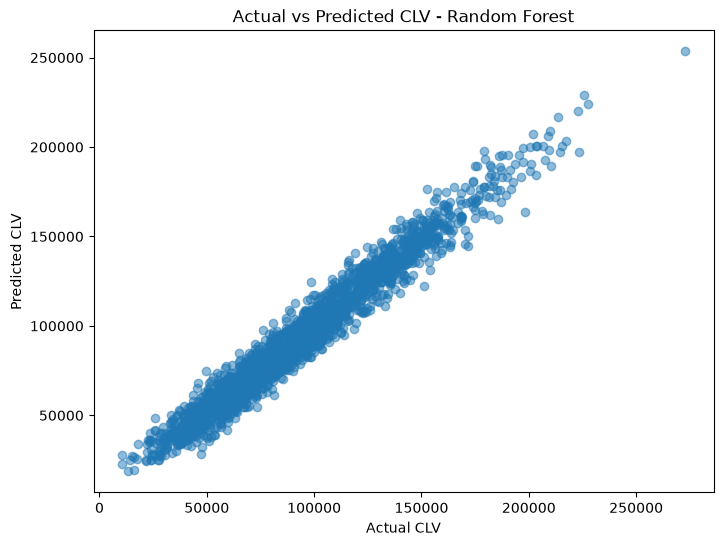

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_clv_test, random_forest_predictions, alpha=0.5)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV - Random Forest")
plt.show()

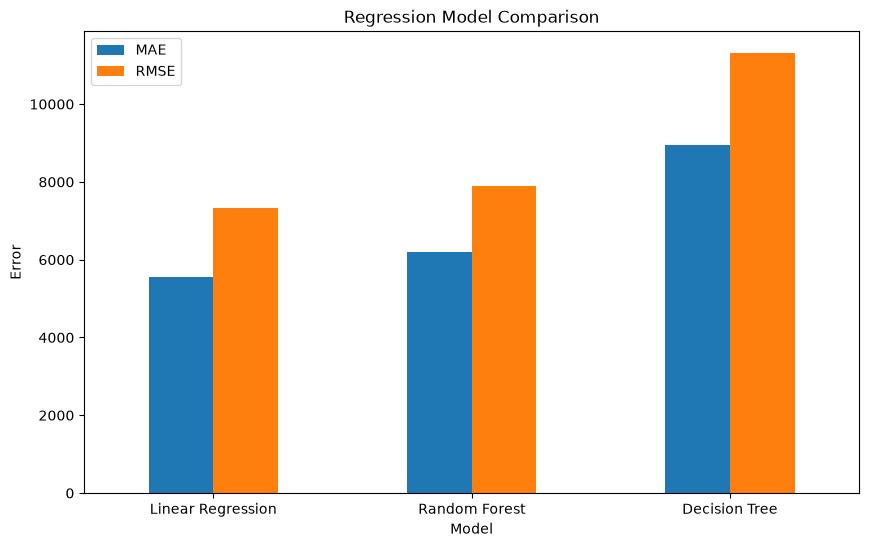

In [99]:
model_comparison.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regression Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

In [100]:
best_model_name = model_comparison.iloc[0]["Model"]

print("Best Regression Model:", best_model_name)
print(model_comparison.iloc[0])

Best Regression Model: Linear Regression
Model           Linear Regression
MAE                   5560.475269
RMSE                  7317.297846
R2                       0.967371
MAE Rank                      1.0
RMSE Rank                     1.0
R2 Rank                       1.0
Overall Rank                  3.0
Name: 0, dtype: object


In [101]:
model_comparison.to_csv("../data/processed/regression_results.csv", index=False)

In [102]:
regression_results = pd.read_csv("../data/processed/regression_results.csv")
regression_results

,Model,MAE,RMSE,R2,MAE Rank,RMSE Rank,R2 Rank,Overall Rank
0,Linear Regression,5560.475269,7317.297846,0.967371,1.0,1.0,1.0,3.0
1,Random Forest,6196.945881,7899.207545,0.961975,2.0,2.0,2.0,6.0
2,Decision Tree,8961.296450,11312.710124,0.922011,3.0,3.0,3.0,9.0
